# Chapter 6 — Lexical, Sparse & Multi-Vector Retrieval

> **TL;DR** — Implement **BM25 from scratch** (with the exact scoring formula and worked numbers), run **SPLADE** to see learned term expansion, and implement **ColBERT MaxSim late interaction** in NumPy.

$$score(D,Q) = \sum_{t \in Q} \text{IDF}(t) \cdot \frac{f(t,D) \cdot (k_1 + 1)}{f(t,D) + k_1 \cdot (1 - b + b \cdot \frac{|D|}{avgdl})}$$

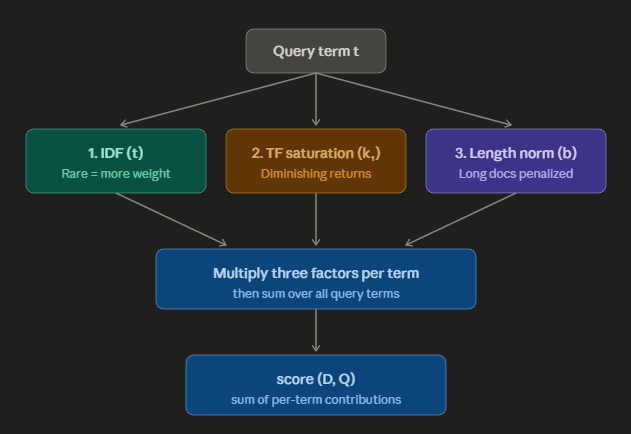

In [2]:
import numpy as np, math
from collections import Counter

class BM25:
    def __init__(self, corpus_tokens, k1=1.5, b=0.75):
        self.k1, self.b = k1, b
        self.docs = corpus_tokens
        self.N = len(corpus_tokens)
        self.doc_len = np.array([len(d) for d in corpus_tokens])
        self.avgdl = self.doc_len.mean()
        self.tf = [Counter(d) for d in corpus_tokens]
        df = Counter(t for d in corpus_tokens for t in set(d))       # document frequency
        self.idf = {t: math.log((self.N - n + 0.5)/(n + 0.5) + 1) for t, n in df.items()}

    def score(self, query_tokens, doc_id):
        s, tf, dl = 0.0, self.tf[doc_id], self.doc_len[doc_id]
        for t in query_tokens:
            if t not in self.idf: continue
            f = tf[t]
            num = f * (self.k1 + 1)
            den = f + self.k1 * (1 - self.b + self.b * dl / self.avgdl)
            s += self.idf[t] * num / den
        return s

    def search(self, query_tokens, k=10):
        scores = np.array([self.score(query_tokens, i) for i in range(self.N)])
        return np.argsort(-scores)[:k], scores

**Worked example** — corpus of 3 docs, query `["refund", "window"]`:

In [2]:
corpus = [["the","refund","window","is","30","days"],
          ["refund","refund","refund","policy"],          # keyword-stuffed
          ["shipping","takes","5","days"]]
bm25 = BM25(corpus)
print(bm25.idf["refund"])          # appears in 2/3 docs → low-ish IDF
print(bm25.idf["window"])          # appears in 1/3 docs → higher IDF (more discriminative)
print(bm25.search(["refund","window"]))

0.47000362924573563
0.9808292530117263
(array([0, 1, 2]), array([1.28554812, 0.81235195, 0.        ]))


Notice doc 1 stuffed "refund" ×3 but **TF saturation** (`k1`) means the 3rd occurrence adds little, and it lacks the discriminative "window" — so doc 0 wins. That's the whole point of `k1` (diminishing returns) and IDF (rare = discriminative) demonstrated in one run. Lower `k1` → more saturation; `b=0` disables length normalization.

In [3]:
from rank_bm25 import BM25Okapi
bm = BM25Okapi(corpus)
print(bm.get_scores(["refund","window"]))

[0.52052484 0.13243627 0.        ]


## 6.2 The crossover — BM25 vs dense, measured

In [3]:
import numpy as np
from sentence_transformers import SentenceTransformer

emb = SentenceTransformer("all-MiniLM-L6-v2")

docs = ["Refunds are issued within 30 days.",
        "Error code X7-4420B indicates a temperature sensor fault.",
        "Our return policy allows money back after purchase."]
tok = lambda s: s.lower().replace(".","").split()
bm25 = BM25([tok(d) for d in docs])
D = emb.encode(docs, normalize_embeddings=True)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7363.57it/s]


In [4]:
def compare(q):
    b = bm25.search(tok(q))[0][0]                          # top BM25 doc
    d = int(np.argmax(emb.encode(q, normalize_embeddings=True) @ D.T))
    print(f"{q!r:45s}  BM25->{b}  dense->{d}")

In [5]:
compare("how do I get my money back")     # dense wins (paraphrase, no shared tokens)
compare("X7-4420B")                        # BM25 wins (exact rare token)

'how do I get my money back'                   BM25->2  dense->2
'X7-4420B'                                     BM25->1  dense->1


## 6.3 SPLADE — learned sparse, see the expansion

SPLADE outputs a weight per vocabulary term via the MLM head + ReLU + log saturation; most weights are 0 (sparse). The revealing part is *term expansion* — terms not in the text get nonzero weight:

In [6]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

tok = AutoTokenizer.from_pretrained("naver/splade-cocondenser-ensembledistil")
mdl = AutoModelForMaskedLM.from_pretrained("naver/splade-cocondenser-ensembledistil")

def splade_vec(text):
    inp = tok(text, return_tensors="pt")
    logits = mdl(**inp).logits                                   # (1, T, vocab)
    # SPLADE pooling: max over tokens of log(1+relu(logits))
    vec = torch.max(torch.log1p(torch.relu(logits)) * inp["attention_mask"].unsqueeze(-1),
                    dim=1).values.squeeze()
    return vec                                                   # (vocab,), sparse


Loading weights: 100%|██████████| 204/204 [00:00<00:00, 22629.94it/s]


In [8]:
v = splade_vec("what is the refund window")
top = torch.topk(v, 10)
print([(tok.decode([i]), round(float(w),2)) for w, i in zip(top.values, top.indices)])
# prints refund/window PLUS expansions like "return", "policy", "days" — terms not in the query

[('window', 2.7), ('ref', 2.62), ('##und', 2.23), ('windows', 2.18), ('return', 1.65), ('tax', 1.51), ('glass', 0.78), ('portal', 0.74), ('restoration', 0.64), ('"', 0.61)]


Because the vector is over the vocabulary and sparse, it's served by an **inverted index** (like BM25) — we get exact-match + expansion at inverted-index cost. Dot product of two SPLADE vectors = the relevance score.

## 6.4 ColBERT MaxSim — late interaction in NumPy

One vector per token; score = sum over query tokens of the max similarity to any doc token:

In [9]:
import numpy as np

def maxsim(Q, D):
    """Q: (nq, d) query token embeddings; D: (nd, d) doc token embeddings. Both unit-normed."""
    sim = Q @ D.T                       # (nq, nd) all query-token × doc-token similarities
    return sim.max(axis=1).sum()        # each query token -> its best doc token, summed

# toy: 3 query tokens, two candidate docs with 4 tokens each
rng = np.random.default_rng(0)
Q  = rng.standard_normal((3, 16)); Q  /= np.linalg.norm(Q, axis=1, keepdims=True)
D1 = rng.standard_normal((4, 16)); D1 /= np.linalg.norm(D1, axis=1, keepdims=True)
D2 = rng.standard_normal((4, 16)); D2 /= np.linalg.norm(D2, axis=1, keepdims=True)
print("MaxSim D1:", round(maxsim(Q, D1), 3), " D2:", round(maxsim(Q, D2), 3))

MaxSim D1: 1.107  D2: 0.549


**Why it's robust:** each query token independently finds its best match, so a paraphrase token and an exact-term token can *both* score well — unlike a single pooled vector where they'd average. **Why it's expensive:** we store one vector per token (~100× a single-vector index) and the store must support MaxSim.

Storage math (from Ch 3.2): 1M docs × ~120 tokens × 128-dim fp16 ≈ **30 GB** vs ~0.5 GB single-vector. ColBERTv2 fixes this with residual/centroid compression (a PQ cousin, Ch 15). Production use via `RAGatouille`:

In [12]:
from ragatouille import RAGPretrainedModel
rag = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")
rag.index(collection=docs, index_name="demo")
print(rag.search("refund window", k=3))     # MaxSim retrieval, compression handled for you

C:\Users\ksdiw\AppData\Local\Temp\ipykernel_22308\3737847582.py:1: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


ModuleNotFoundError: No module named 'langchain.retrievers'

## 6.5 The three on one axis

| | Dense (1 vec) | SPLADE (sparse) | ColBERT (multi-vec) |
|---|---|---|---|
| Vectors/doc | 1 | 1 (sparse over vocab) | ~1/token |
| Index | ANN (HNSW/IVF) | inverted | late-interaction store |
| Exact match | weak (averaging) | strong | strong |
| Semantics | strong | good (expansion) | strong |
| Storage | ×1 | small | **~×100** |
| Interaction | none (cosine) | none (dot) | MaxSim (late) |